In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('Health_Sleep_Statistics.csv')

Comparar la cantidad de pasos diarios entre personas con hábitos
alimenticios saludables y no saludables.


In [4]:
df.head()

,User ID,Age,Gender,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage
0,1,25,f,8,23:00,06:30,8000,2500,medium,healthy,no,no
1,2,34,m,7,00:30,07:00,5000,2200,low,unhealthy,yes,yes
2,3,29,f,9,22:45,06:45,9000,2700,high,healthy,no,no
3,4,41,m,5,01:00,06:30,4000,2100,low,unhealthy,yes,no
4,5,22,f,8,23:30,07:00,10000,2800,high,medium,no,no


In [8]:
healthy_steps = df[df['Dietary Habits'] == 'healthy']['Daily Steps']
unhealthy_steps = df[df['Dietary Habits'] == 'unhealthy']['Daily Steps']


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

<h3>Boxplot

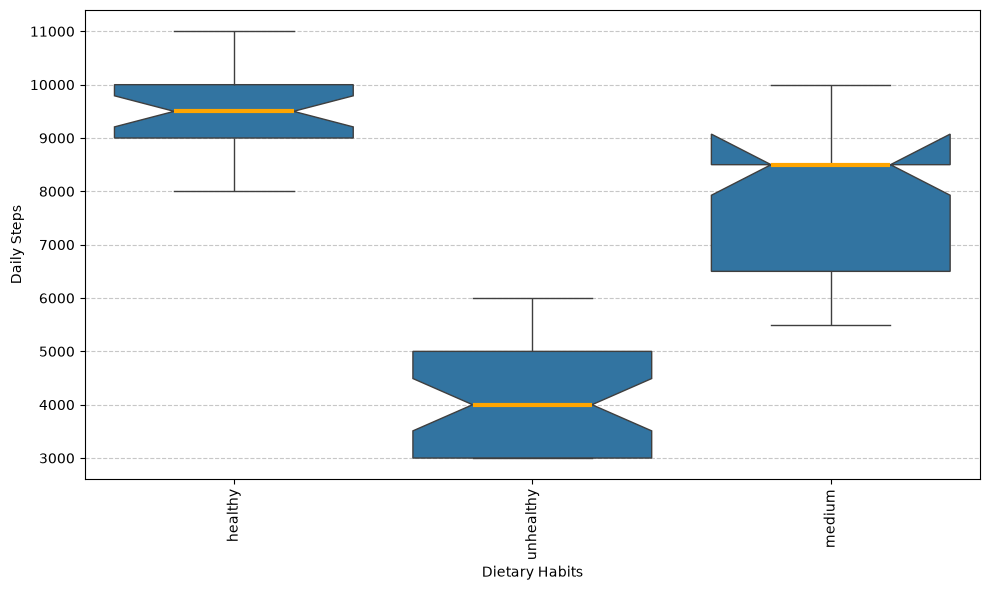

In [10]:
utils.box_plot('Dietary Habits', 'Daily Steps', df, note=True)

<h3>Normalidad

In [12]:
import scipy.stats as stats

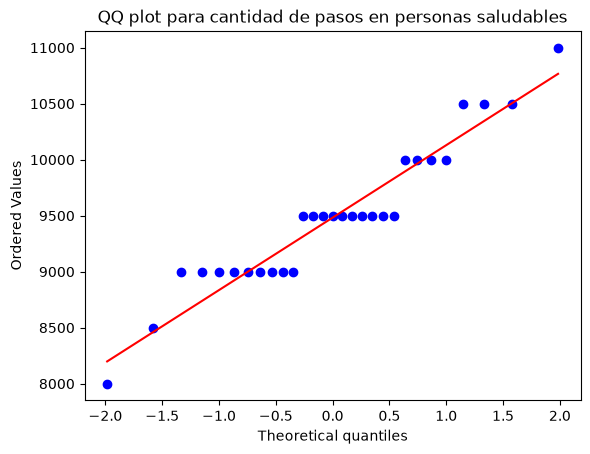

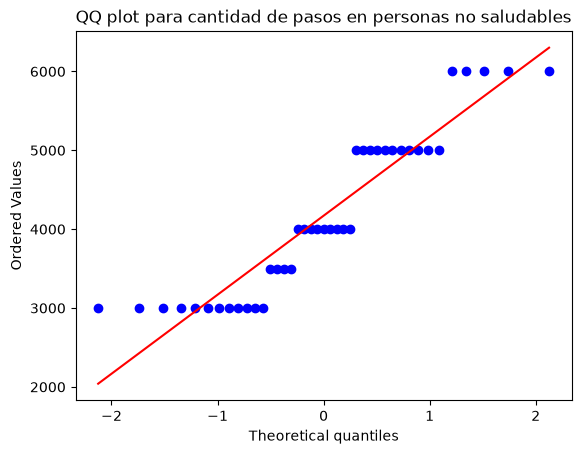

In [17]:
#QQ plot
stats.probplot(healthy_steps, dist='norm', plot=plt)
plt.title('QQ plot para cantidad de pasos en personas saludables')
plt.show()

stats.probplot(unhealthy_steps, dist='norm', plot=plt)
plt.title('QQ plot para cantidad de pasos en personas no saludables')
plt.show()

In [14]:
from scipy.stats import shapiro

In [18]:
stat, p = shapiro(healthy_steps)
print(f"Test de Shapiro-Wilk para pasos diarios en personas saludables: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para pasos diarios en personas saludables: Estadístico=0.931, p-valor=0.059


In [16]:
stat, p = shapiro(unhealthy_steps)
print(f"Test de Shapiro-Wilk para pasos diarios en personas no saludables: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para pasos diarios en personas no saludables: Estadístico=0.866, p-valor=0.000


Vemos que las personas saludables si siguen una distribucion normal, pero las no saludables no, por lo que no tenemos normalidad

<h3>Homocedasticidad

In [20]:
stat, p = stats.levene(healthy_steps, unhealthy_steps)
print(f"Test de Levene para cantidad de pasos: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para cantidad de pasos: Estadístico=8.884, p-valor=0.004


Existen diferencias significativas en las varianzas, por lo que usamos Kruskal

<h3>Kruskal

In [22]:
stat, p = stats.kruskal(healthy_steps, unhealthy_steps)
print(f"Test de Kruskal-Wallis para cantidad de pasos: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en la cantidad de pasos diarios entre personas saludables y no saludables.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en la cantidad de pasos diarios entre personas saludables y no saludables.")

Test de Kruskal-Wallis para cantidad de pasos: Estadístico=51.093, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en la cantidad de pasos diarios entre personas saludables y no saludables.
